# Plot: fluxes and time lag used

For each analyzer (QCL, LGR) and gas (N2O, CH4), a combined figure showing the
**flux in the top panels** and the **time lag used in the bottom panels**, with
the three lag variants ([processing versions](../docs/processing-versions.md))
as columns. This lines up each variant's flux directly above the lag that
produced it.

Data come from the column subsets (`data/02-…_subsets/`). Four figures are
saved: `figures/03_{qcl,lgr}_{n2o,ch4}.png`. These are **intermediate** figures
(small size / low DPI); bump `FIGSIZE` / `DPI` for publication-ready output.

## Imports

In [26]:
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

from diive.core.io.files import load_parquet

NB_START = datetime.now()  # notebook start time (reported in the last cell)

## Configuration

In [27]:
SUBSETDIR = Path("../data/02-eddypro_fluxes_level-1_parquet_subsets")
FIGDIR = Path("../figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

# Figure size / resolution. Kept small here — these are intermediate figures.
# 12 x 6 inches at 100 DPI = 1200 x 600 px. Increase for publication output.
FIGSIZE = (12, 6)
DPI = 150

# One figure per analyzer x gas. Columns of each figure = that analyzer's variants.
ANALYZERS = {
    "QCL": ["QCL-1", "QCL-2R", "QCL-3"],
    "LGR": ["LGR-1", "LGR-2R", "LGR-3"],
}
# Per gas: the flux variable (top row) and the time-lag-used variable (bottom row).
GASES = {
    "N2O": {"flux": "FN2O", "lag": "N2O_TLAG_USED"},
    "CH4": {"flux": "FCH4", "lag": "CH4_TLAG_USED"},
}
# Distinct colors for the two rows (ColorBrewer Dark2): flux vs. lag.
FLUX_COLOR = "#1b9e77"  # teal
LAG_COLOR = "#d95f02"   # orange

# Robust flux y-range: clip the flux axis to this percentile range (per figure)
# so outliers don't flatten the signal. The lag axis is left to autoscale.
PCTL = (1, 99)

# Load the needed subsets.
codes = [c for variants in ANALYZERS.values() for c in variants]
data = {c: load_parquet(filepath=str(SUBSETDIR / f"{c}.parquet")) for c in codes}
for c in codes:
    print(f"{c}: {data[c].shape[0]} rows, {data[c].index.min()} -> {data[c].index.max()}")

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-1.parquet (0.006 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-2R.parquet (0.005 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\QCL-3.parquet (0.006 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-1.parquet (0.006 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-2R.parquet (0.004 seconds).

> Loaded .parquet file ..\data\02-eddypro_fluxes_level-1_parquet_subsets\LGR-3.parquet (0.005 seconds).

QCL-1: 9642 rows, 2020-12-31 19:15:00 -> 2021-07-20 15:45:00
QCL-2R: 9642 rows, 2020-12-31 19:15:00 -> 2021-07-20 15:45:00
QCL-3: 20790 rows, 2020-05-13 13:15:00 -> 2021-07-20 15:45:00
LGR-1: 7805 rows, 2021-07-22 10:45:00 -> 2022-01-01 00:45:00
LGR-2R: 7805 rows, 2021-07-22 10:45:00 -> 2022-01-01 00:45:00
LGR-3: 16768 rows, 2021-07-22 10:45:00 -> 2022-07-06 18:15:00


## Figures

One figure per analyzer x gas: flux (top) over time lag used (bottom), variants
as columns.

Saved ..\figures\03_qcl_n2o.png


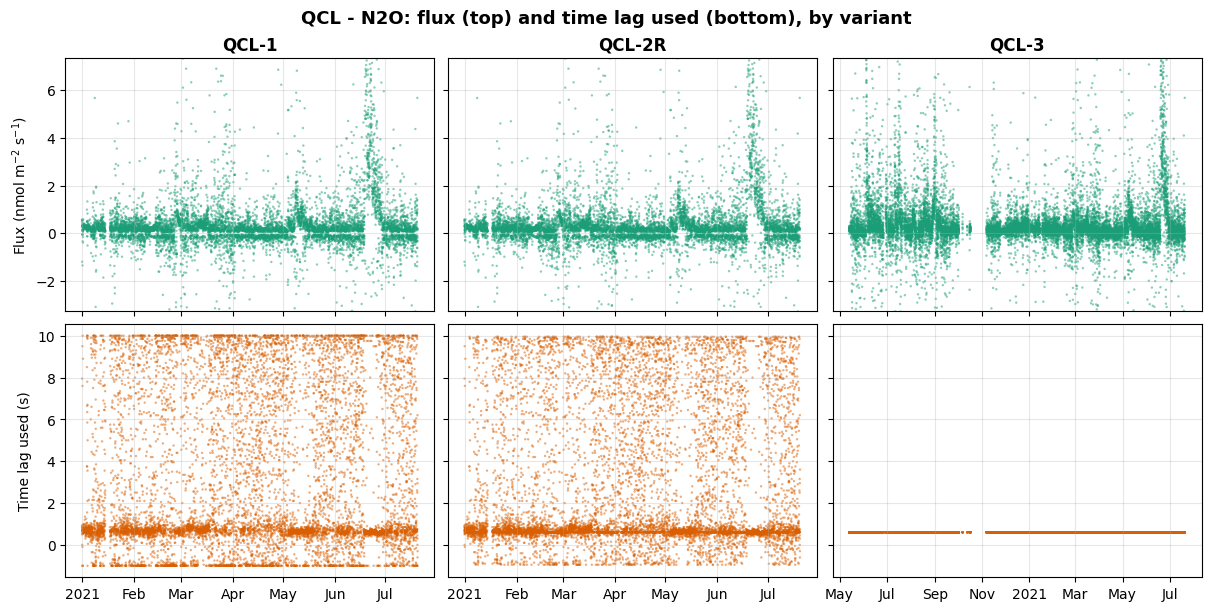

Saved ..\figures\03_qcl_ch4.png


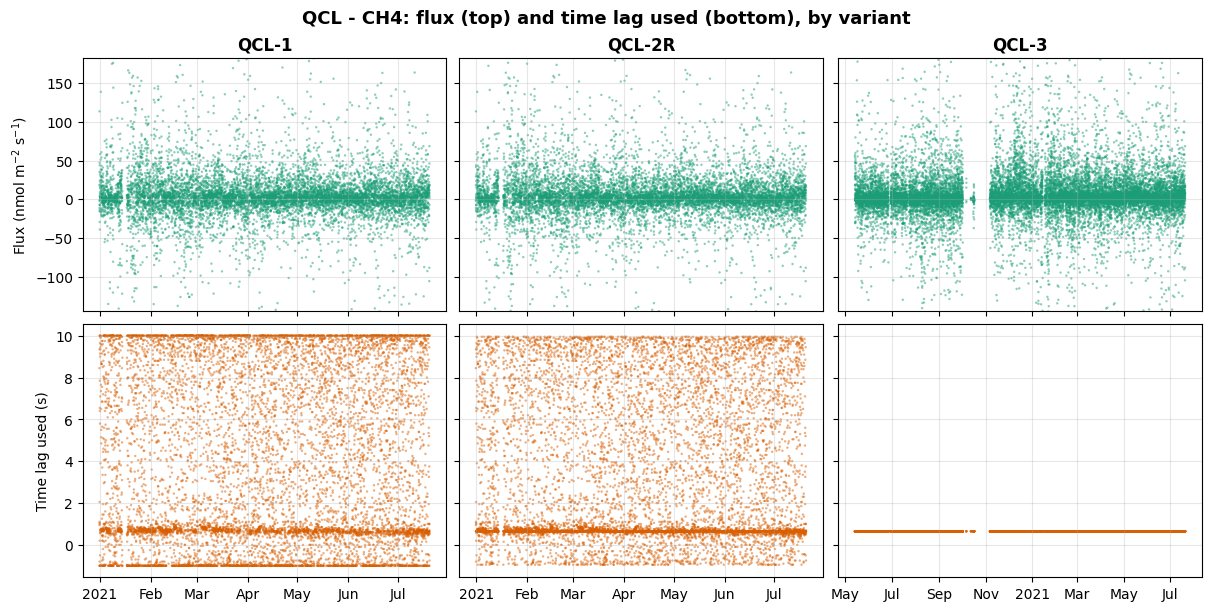

Saved ..\figures\03_lgr_n2o.png


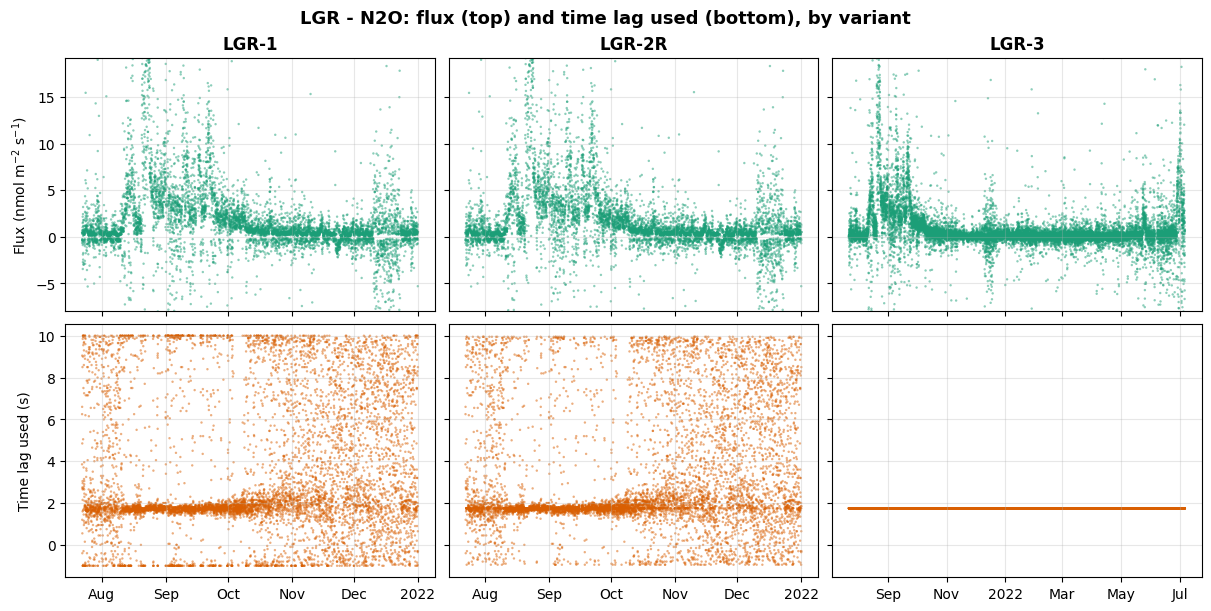

Saved ..\figures\03_lgr_ch4.png


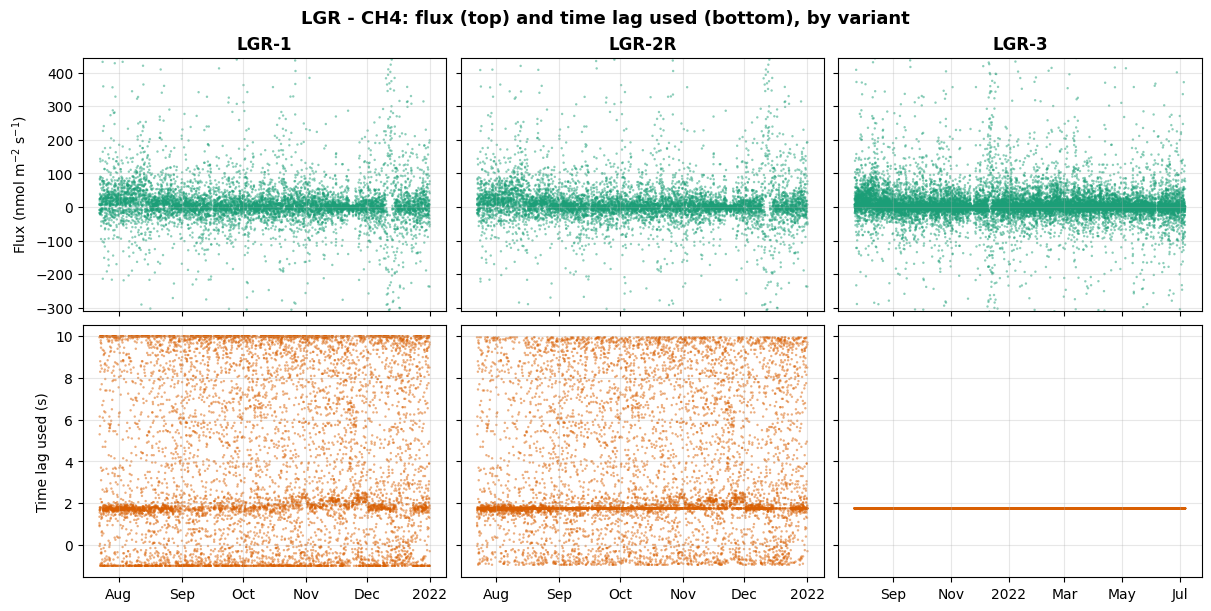

In [28]:
def robust_ylim(values, pctl=PCTL, pad_frac=0.05):
    """Percentile-based y-limits with a small symmetric pad."""
    lo, hi = np.nanpercentile(values, pctl)
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


for analyzer, variants in ANALYZERS.items():
    for gas, v in GASES.items():
        fluxvar, lagvar = v["flux"], v["lag"]

        # Robust flux range across this figure's variants.
        flux_vals = np.concatenate([data[c][fluxvar].to_numpy().ravel() for c in variants])
        flux_ylim = robust_ylim(flux_vals)

        fig, axes = plt.subplots(
            nrows=2, ncols=len(variants),
            figsize=FIGSIZE,
            sharex="col",   # flux and its lag share the time axis
            sharey="row",   # all flux panels share scale; all lag panels share scale
            constrained_layout=True,
        )

        for ci, code in enumerate(variants):
            df = data[code]

            # Top: flux
            ax_top = axes[0, ci]
            ax_top.scatter(df.index, df[fluxvar], s=3, alpha=0.5,
                           color=FLUX_COLOR, edgecolors="none")
            ax_top.set_title(code, fontweight="bold")
            ax_top.grid(True, alpha=0.3)
            ax_top.set_ylim(flux_ylim)

            # Bottom: time lag used
            ax_bot = axes[1, ci]
            ax_bot.scatter(df.index, df[lagvar], s=3, alpha=0.5,
                           color=LAG_COLOR, edgecolors="none")
            ax_bot.grid(True, alpha=0.3)
            loc = mdates.AutoDateLocator()
            ax_bot.xaxis.set_major_locator(loc)
            ax_bot.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

        axes[0, 0].set_ylabel("Flux (nmol m$^{-2}$ s$^{-1}$)")
        axes[1, 0].set_ylabel("Time lag used (s)")
        fig.suptitle(f"{analyzer} - {gas}: flux (top) and time lag used (bottom), by variant",
                     fontsize=13, fontweight="bold")

        out = FIGDIR / f"03_{analyzer.lower()}_{gas.lower()}.png"
        fig.savefig(out, dpi=DPI, bbox_inches="tight")
        print(f"Saved {out}")
        plt.show()

## Runtime

In [29]:
NB_END = datetime.now()
print(f"Start:    {NB_START:%Y-%m-%d %H:%M:%S}")
print(f"End:      {NB_END:%Y-%m-%d %H:%M:%S}")
print(f"Runtime:  {NB_END - NB_START}")

Start:    2026-06-04 15:07:54
End:      2026-06-04 15:08:09
Runtime:  0:00:15.421598
